# Brain Tumor Segmentation on BRISC 2025
## YOLO26n-seg

This notebook attempt to apply segmentation on the BRISC 2025 dataset, a recent expert-annotated
collection of 6,000 T1-weighted brain MRI scans published in Scientific Data
(Fateh et al., 2026).

**Dataset**: BRISC 2025 — 4,793 segmentation pairs across 3 tumor classes (glioma,
meningioma, pituitary), annotated by certified radiologists across axial, coronal,
and sagittal planes.

**preproccing of data is done with the help of shrinidhi KJ notebook**

In [1]:
!pip install ultralytics opencv-python-headless -U -q
!pip install onnx onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 98.3 MB/s eta 0:00:00:00:010:01


In [2]:
import os
import glob
import shutil
import random
import time
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from ultralytics import YOLO
import torch
 
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
 
print(f"Ultralytics: {__import__('ultralytics').__version__}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
 
# Kaggle mounts dataset at /kaggle/input/<slug>/<top-folder>
# The actual content sits one level deeper
DATASET_ROOT = Path("/kaggle/input/datasets/briscdataset/brisc2025/brisc2025")
WORK_DIR = Path("/kaggle/working")
YOLO_DATASET = WORK_DIR / "brisc_yolo_seg"
 
# BRISC filenames encode the tumor type as a 2-letter code:
#   brisc2025_train_00001_gl_ax_t1.jpg
#   gl = glioma, me = meningioma, pi = pituitary, nt = no_tumor
# We only use the 3 tumor classes for segmentation (no_tumor has no mask).
CODE_TO_CLASS = {"gl": 0, "me": 1, "pi": 2}
CLASS_NAMES = ["glioma", "meningioma", "pituitary"]
NUM_CLASSES = 3
 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.37
PyTorch: 2.9.0+cu126, CUDA: True
GPU: Tesla P100-PCIE-16GB


In [3]:
# The segmentation_task has a flat layout:
#   segmentation_task/train/images/*.jpg  (all classes mixed together)
#   segmentation_task/train/masks/*.png   (matching basenames)
# No class subfolders under images/ or masks/.
print("Top level:")
for item in sorted(DATASET_ROOT.iterdir()):
    print(f"  {item.name}")
 
seg_root = DATASET_ROOT / "segmentation_task"
print("\nSegmentation task:")
for split_dir in sorted(seg_root.iterdir()):
    if not split_dir.is_dir():
        continue
    print(f"  {split_dir.name}/")
    for sub in sorted(split_dir.iterdir()):
        if sub.is_dir():
            n = len(list(sub.iterdir()))
            print(f"    {sub.name}/  ({n} files)")
 
# show a few filenames to confirm the naming pattern
train_imgs = sorted((seg_root / "train" / "images").glob("*"))
print(f"\nFirst 5 training image filenames:")
for f in train_imgs[:5]:
    print(f"  {f.name}")
 
train_masks = sorted((seg_root / "train" / "masks").glob("*"))
print(f"\nFirst 5 training mask filenames:")
for f in train_masks[:5]:
    print(f"  {f.name}")

Top level:
  README.md
  classification_task
  manifest.csv
  manifest.csv.sha256
  manifest.json
  manifest.json.sha256
  segmentation_task

Segmentation task:
  test/
    images/  (860 files)
    masks/  (860 files)
  train/
    images/  (3933 files)
    masks/  (3933 files)

First 5 training image filenames:
  brisc2025_train_00001_gl_ax_t1.jpg
  brisc2025_train_00002_gl_ax_t1.jpg
  brisc2025_train_00003_gl_ax_t1.jpg
  brisc2025_train_00004_gl_ax_t1.jpg
  brisc2025_train_00005_gl_ax_t1.jpg

First 5 training mask filenames:
  brisc2025_train_00001_gl_ax_t1.png
  brisc2025_train_00002_gl_ax_t1.png
  brisc2025_train_00003_gl_ax_t1.png
  brisc2025_train_00004_gl_ax_t1.png
  brisc2025_train_00005_gl_ax_t1.png


## Mask to YOLO polygon conversion

BRISC provides binary PNG masks. YOLO segmentation models need
normalised polygon coordinates in text files. The pipeline is:

1. Read mask, threshold to binary
2. Find contours with OpenCV
3. Simplify with approxPolyDP (epsilon = 0.002 * perimeter)
4. Normalise coordinates to 0-1 range
5. Write YOLO-seg format: class_id x1 y1 x2 y2 ... xN yN

Epsilon 0.002 is chosen to keep enough boundary detail for
clinical relevance while avoiding excessive polygon vertices
that slow down training.

The BRISC 2025 segmentation subset contains 3,933 training and 860 test
image-mask pairs. Images are contrast-enhanced T1-weighted MRI stored as
JPEG, with corresponding binary PNG masks at native resolution. The dataset
uses a flat folder structure with class identity encoded in filenames using
two-letter codes (gl=glioma, me=meningioma, pi=pituitary, nt=no_tumor).

No_tumor samples are excluded from the segmentation task since they have
blank masks and contribute no training signal for instance segmentation.

In [4]:
# parse tumor class from BRISC filename
# pattern: brisc2025_<split>_<index>_<tumor_code>_<plane>_<seq>.<ext>
# tumor_code is the 4th part: gl=glioma, me=meningioma, pi=pituitary, nt=no_tumor
CODE_TO_CLASS = {"gl": 0, "me": 1, "pi": 2}

def get_class_id_from_filename(filename):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) >= 4:
        return CODE_TO_CLASS.get(parts[3], None)
    return None

# quick test
for name in ["brisc2025_train_00001_gl_ax_t1.jpg",
             "brisc2025_train_00100_me_co_t1.jpg",
             "brisc2025_train_00200_pi_sa_t1.jpg",
             "brisc2025_train_00300_nt_ax_t1.jpg"]:
    print(f"  {name} -> class_id={get_class_id_from_filename(name)}")

  brisc2025_train_00001_gl_ax_t1.jpg -> class_id=0
  brisc2025_train_00100_me_co_t1.jpg -> class_id=1
  brisc2025_train_00200_pi_sa_t1.jpg -> class_id=2
  brisc2025_train_00300_nt_ax_t1.jpg -> class_id=None


In [5]:
# parse tumor class from BRISC filename
CODE_TO_CLASS = {"gl": 0, "me": 1, "pi": 2}

def get_class_id_from_filename(filename):
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) >= 4:
        return CODE_TO_CLASS.get(parts[3], None)
    return None


def mask_to_yolo_polygons(mask_path, class_id, epsilon_factor=0.002, min_area_frac=0.0005):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []
    h, w = mask.shape
    img_area = h * w
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lines = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_frac * img_area:
            continue
        perimeter = cv2.arcLength(cnt, True)
        epsilon = epsilon_factor * perimeter
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        if len(approx) < 3:
            continue
        coords = []
        for point in approx:
            px, py = point[0]
            coords.append(f"{px / w:.6f}")
            coords.append(f"{py / h:.6f}")
        line = f"{class_id} " + " ".join(coords)
        lines.append(line)
    return lines


# convert and split in one pass
if YOLO_DATASET.exists():
    shutil.rmtree(YOLO_DATASET)

seg_root = DATASET_ROOT / "segmentation_task"

train_img_names = sorted(os.listdir(seg_root / "train" / "images"))
random.shuffle(train_img_names)
val_count = int(len(train_img_names) * 0.15)
val_set = set(train_img_names[:val_count])

for folder in ["train", "val", "test"]:
    (YOLO_DATASET / "images" / folder).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET / "labels" / folder).mkdir(parents=True, exist_ok=True)

stats = {"train": Counter(), "val": Counter(), "test": Counter(),
         "skipped_no_class": 0, "skipped_empty": 0}

for src_split in ["train", "test"]:
    src_img_dir = seg_root / src_split / "images"
    src_mask_dir = seg_root / src_split / "masks"

    for img_name in sorted(os.listdir(src_img_dir)):
        img_path = src_img_dir / img_name
        stem = Path(img_name).stem

        class_id = get_class_id_from_filename(img_name)
        if class_id is None:
            stats["skipped_no_class"] += 1
            continue

        mask_path = src_mask_dir / f"{stem}.png"
        if not mask_path.exists():
            continue

        lines = mask_to_yolo_polygons(mask_path, class_id)
        if not lines:
            stats["skipped_empty"] += 1
            continue

        if src_split == "test":
            dst_split = "test"
        elif img_name in val_set:
            dst_split = "val"
        else:
            dst_split = "train"

        shutil.copy2(img_path, YOLO_DATASET / "images" / dst_split / f"{stem}.jpg")
        with open(YOLO_DATASET / "labels" / dst_split / f"{stem}.txt", "w") as f:
            f.write("\n".join(lines) + "\n")

        stats[dst_split][CLASS_NAMES[class_id]] += 1

for split in ["train", "val", "test"]:
    n = len(os.listdir(YOLO_DATASET / "images" / split))
    print(f"{split}: {n} images, classes: {dict(stats[split])}")

print(f"Skipped no class: {stats['skipped_no_class']}, empty mask: {stats['skipped_empty']}")

data_yaml_content = f"""path: {YOLO_DATASET}
train: images/train
val: images/val
test: images/test

nc: {NUM_CLASSES}
names: {CLASS_NAMES}"""

data_yaml_path = YOLO_DATASET / "data.yaml"
with open(data_yaml_path, "w") as f:
    f.write(data_yaml_content)

print(f"\ndata.yaml:\n{data_yaml_content}")

train: 3342 images, classes: {'glioma': 992, 'meningioma': 1128, 'pituitary': 1222}
val: 589 images, classes: {'glioma': 154, 'meningioma': 200, 'pituitary': 235}
test: 860 images, classes: {'glioma': 254, 'meningioma': 306, 'pituitary': 300}
Skipped no class: 0, empty mask: 2

data.yaml:
path: /kaggle/working/brisc_yolo_seg
train: images/train
val: images/val
test: images/test

nc: 3
names: ['glioma', 'meningioma', 'pituitary']


In [6]:
# Apply NLM denoising to enhance images befor training
print("Applying Non-local Means Denoising to images...")

# Parameters for non-local means denoising
denoise_h = 10
denoise_hColor = 10
denoise_templateWindowSize = 7
denoise_searchWindowSize = 21

processed_count = 0
for split in ["train", "val", "test"]:
    image_dir = YOLO_DATASET / "images" / split
    if image_dir.exists():
        for img_path in image_dir.glob("*.jpg"):
            img = cv2.imread(str(img_path))
            if img is not None:
                # Apply non-local means denoising
                denoised_img = cv2.fastNlMeansDenoisingColored(
                    img,
                    None,
                    denoise_h,
                    denoise_hColor,
                    denoise_templateWindowSize,
                    denoise_searchWindowSize
                )
                cv2.imwrite(str(img_path), denoised_img) # Overwrite original with denoised
                processed_count += 1

print(f"Denoising complete. Processed {processed_count} images.")

Applying Non-local Means Denoising to images...
Denoising complete. Processed 4791 images.


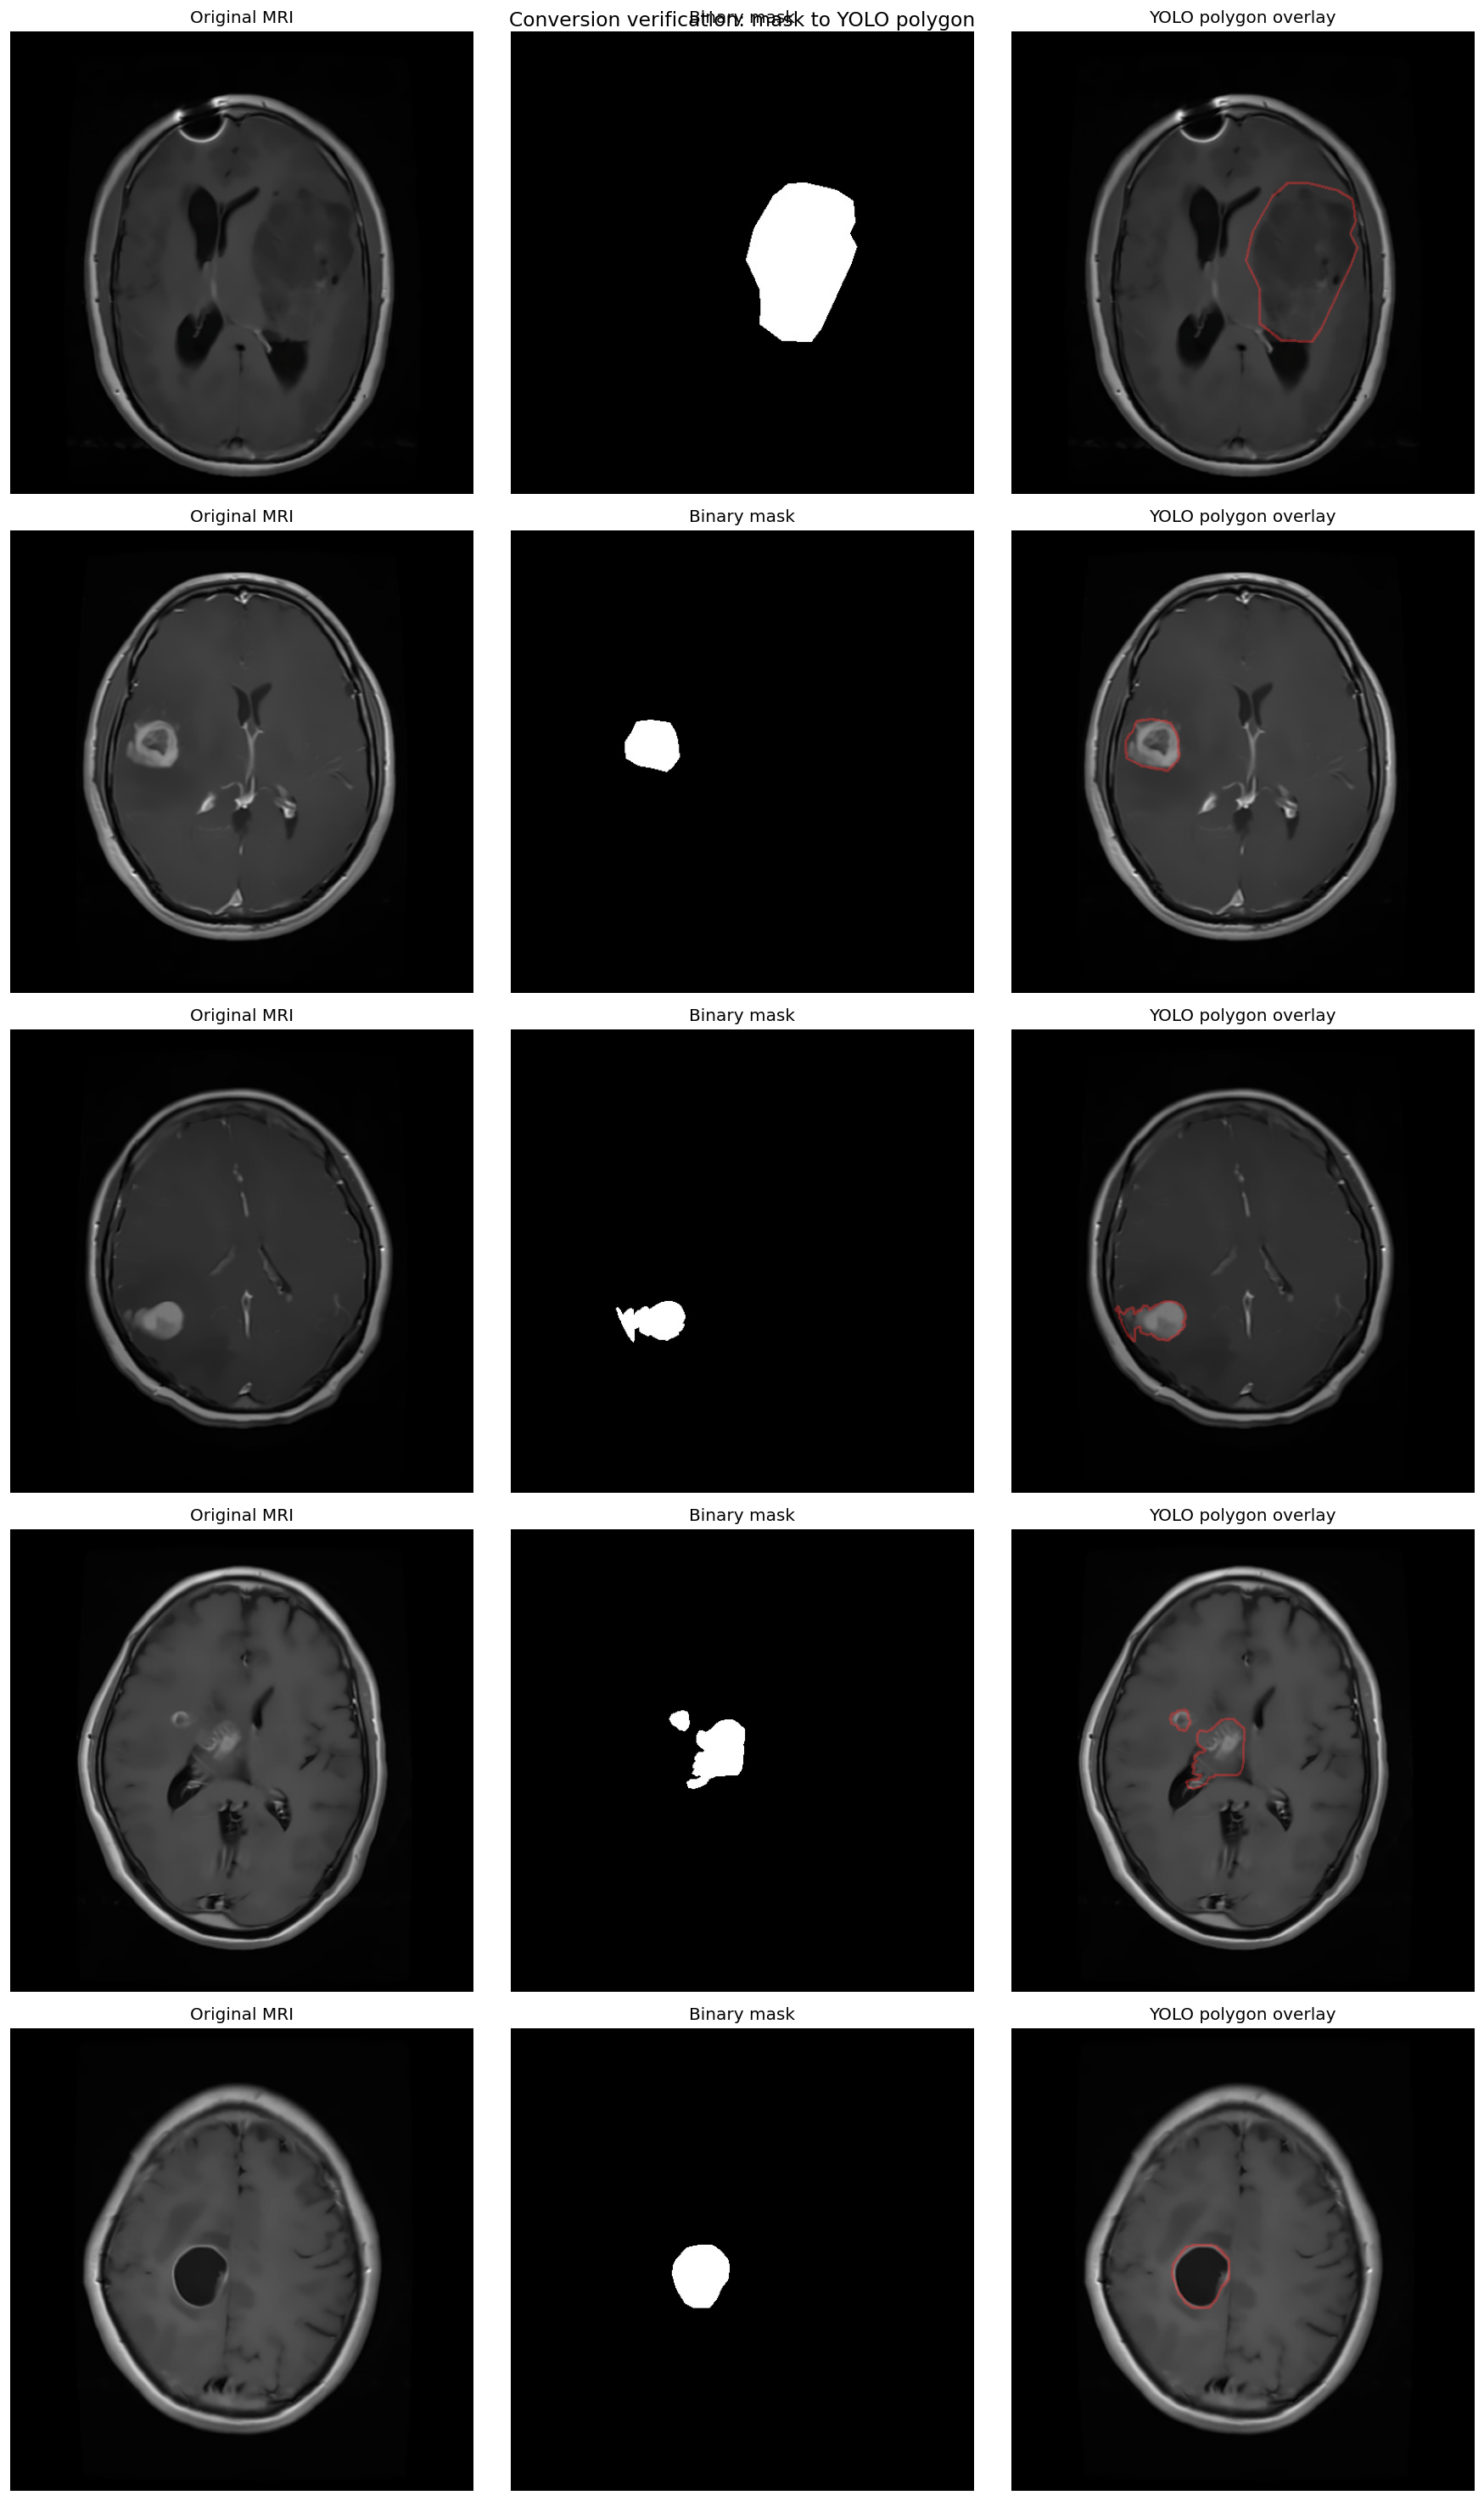

In [7]:
# Shows original image, binary mask, and the polygon overlay side by side.

COLORS = {0: (255, 50, 50), 1: (50, 255, 50), 2: (50, 50, 255)}

sample_labels = sorted((YOLO_DATASET / "labels" / "train").glob("*.txt"))[:5]
if len(sample_labels) < 5:
    sample_labels += sorted((YOLO_DATASET / "labels" / "val").glob("*.txt"))[:5 - len(sample_labels)]

fig, axes = plt.subplots(len(sample_labels), 3, figsize=(15, 5 * len(sample_labels)))
if len(sample_labels) == 1:
    axes = axes[np.newaxis, :]

for idx, lbl_path in enumerate(sample_labels):
    stem = lbl_path.stem

    # find image
    img_path = None
    for split in ["train", "val"]:
        candidate = YOLO_DATASET / "images" / split / f"{stem}.jpg"
        if candidate.exists():
            img_path = candidate
            break
    if img_path is None:
        continue

    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # find original mask (flat folder, no class subfolders)
    mask_display = np.zeros((h, w), dtype=np.uint8)
    for split_name in ["train", "test"]:
        m_path = seg_root / split_name / "masks" / f"{stem}.png"
        if m_path.exists():
            mask_display = cv2.imread(str(m_path), cv2.IMREAD_GRAYSCALE)
            break

    # draw polygons from the converted label file
    overlay = img_rgb.copy()
    with open(lbl_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            points = []
            for i in range(0, len(coords), 2):
                px = int(coords[i] * w)
                py = int(coords[i + 1] * h)
                points.append([px, py])
            pts = np.array(points, dtype=np.int32)
            color = COLORS.get(cls_id, (255, 255, 0))
            cv2.polylines(overlay, [pts], True, color, 2)

    blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title("Original MRI")
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(mask_display, cmap="gray")
    axes[idx, 1].set_title("Binary mask")
    axes[idx, 1].axis("off")

    axes[idx, 2].imshow(blended)
    axes[idx, 2].set_title("YOLO polygon overlay")
    axes[idx, 2].axis("off")

plt.suptitle("Conversion verification: mask to YOLO polygon", fontsize=14)
plt.tight_layout()
plt.savefig(WORK_DIR / "conversion_verification.png", dpi=150, bbox_inches="tight")
plt.show()

Instance counts per class:
  glioma: 1544 instances, avg 50.4 polygon points
  meningioma: 1685 instances, avg 61.3 polygon points
  pituitary: 1826 instances, avg 60.7 polygon points


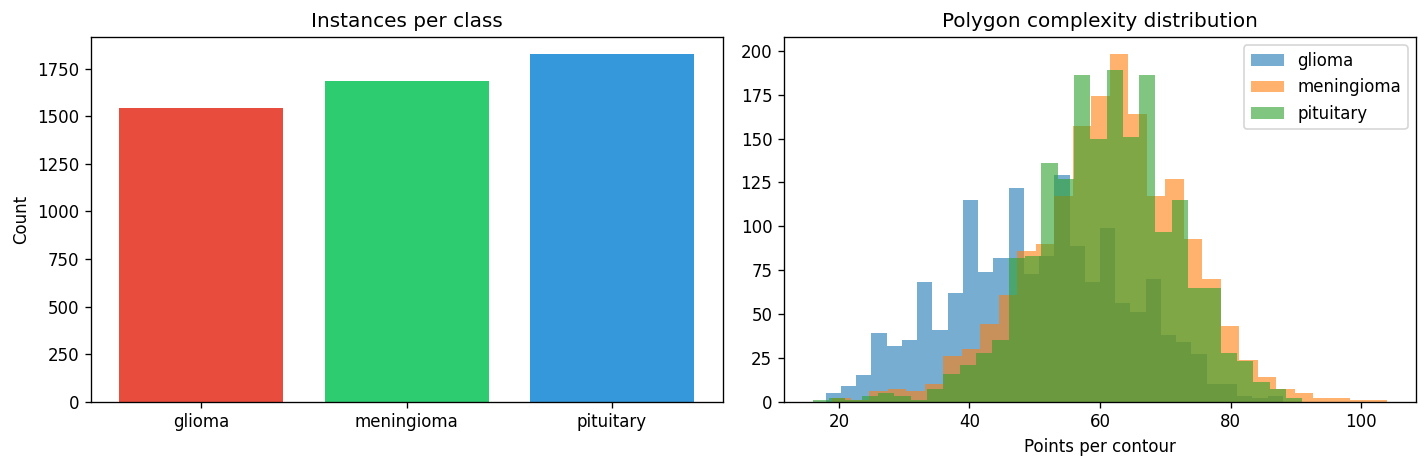

In [8]:
class_counter = Counter()
polygon_sizes = defaultdict(list)

for split in ["train", "val", "test"]:
    lbl_dir = YOLO_DATASET / "labels" / split
    if not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.txt"):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                class_counter[cls_id] += 1
                n_points = (len(parts) - 1) // 2
                polygon_sizes[cls_id].append(n_points)

print("Instance counts per class:")
for cid in sorted(class_counter):
    name = CLASS_NAMES[cid]
    count = class_counter[cid]
    avg_pts = np.mean(polygon_sizes[cid])
    print(f"  {name}: {count} instances, avg {avg_pts:.1f} polygon points")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

names = [CLASS_NAMES[i] for i in sorted(class_counter)]
counts = [class_counter[i] for i in sorted(class_counter)]
ax1.bar(names, counts, color=["#e74c3c", "#2ecc71", "#3498db"])
ax1.set_title("Instances per class")
ax1.set_ylabel("Count")

for cid in sorted(polygon_sizes):
    ax2.hist(polygon_sizes[cid], bins=30, alpha=0.6, label=CLASS_NAMES[cid])
ax2.set_title("Polygon complexity distribution")
ax2.set_xlabel("Points per contour")
ax2.legend()

plt.tight_layout()
plt.savefig(WORK_DIR / "class_distribution.png", dpi=150)
plt.show()

## Training Configuration
optimizer:  YOLO26 uses MuSGD, a hybrid of SGD and Muon inspired by Moonshot AI's Kimi K2
large language model training. MuSGD is designed to provide more stable
convergence on limited data, which is relevant here given that we train
on approximately 3,300 images after the validation split.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| imgsz | 640 | Standard YOLO input, balances resolution vs memory |
| epochs | 50 | Sufficient for convergence on ~3.3K images |
| batch | 16 | Fits P100 16 GB VRAM for nano models |
| patience | 15 | Early stopping to prevent overfitting |
| amp | True | Mixed precision for memory efficiency |
| seed | 42 | Reproducibility |


In [8]:
TRAIN_PARAMS = dict(
    data=str(data_yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    amp=True,
    seed=42,
    task="segment",
    device=0,
    workers=4,
    verbose=True,
    plots=True,
    save=True,
    exist_ok=True,
    #apply class wieghts
    overlap_mask= True,      # handles overlapping masks better
    mask_ratio=2,           # finer mask resolution
    box=7.5,                # increase box loss weight
    cls=0.2,                # decrease classification loss weight
    cls_pw = 0.9,           #Classification Positive Weight
    # imaging augmentation (conservative)
    hsv_h=0.01,
    hsv_s=0.3,
    hsv_v=0.3,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.5,
)

In [9]:
print("Training YOLO26n-seg")

model_26 = YOLO("yolo26n-seg.pt")
results_26 = model_26.train(
    name="yolo26n_seg_brisc",
    project=str(WORK_DIR / "runs"),
    **TRAIN_PARAMS,
)

print("YOLO26n-seg training done.")

Training YOLO26n-seg
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brisc_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_seg_brisc, nbs=64, nms=False, opset=None, optimize=

In [10]:
# save weights so they survive session restarts
!mkdir -p /kaggle/working/saved_weights
!cp /kaggle/working/runs/yolo26n_seg_brisc/weights/best.pt /kaggle/working/saved_weights/yolo26n_seg_best.pt
print("Weights saved.")

cp: cannot stat '/kaggle/working/runs/yolov8n_seg_brisc/weights/best.pt': No such file or directory
Weights saved.


In [11]:
import os
from pathlib import Path

WORK_DIR = Path("/kaggle/working")

v26_best = WORK_DIR / "runs" / "yolo26n_seg_brisc" / "weights" / "best.pt"

print(f"v26 weights exist: {v26_best.exists()}")

# also check if the converted dataset survived
YOLO_DATASET = WORK_DIR / "brisc_yolo_seg"
print(f"Dataset exists: {YOLO_DATASET.exists()}")
if YOLO_DATASET.exists():
    for split in ["train", "val", "test"]:
        p = YOLO_DATASET / "images" / split
        if p.exists():
            print(f"  {split}: {len(os.listdir(p))} images")

v26 weights exist: True
Dataset exists: True
  train: 3342 images
  val: 589 images
  test: 860 images


## Evaluation

Both models are evaluated on the held-out test set (860 images) using standard
COCO-style metrics: box mAP and mask mAP at IoU thresholds 0.50 and 0.50-0.95.
We also compute precision, recall, F1, and an approximate Dice coefficient
derived from mask mAP (Dice = 2*IoU / (1+IoU)).

In [13]:
def evaluate_model(model_path, data_yaml, split="test", name="model"):
    model = YOLO(model_path)
    metrics = model.val(
        data=str(data_yaml),
        split=split,
        imgsz=640,
        batch=16,
        task="segment",
        plots=True,
        save_json=True,
        verbose=True,
    )

    results = {
        "Model": name,
        "Box mAP50": f"{metrics.box.map50:.4f}",
        "Box mAP50-95": f"{metrics.box.map:.4f}",
        "Mask mAP50": f"{metrics.seg.map50:.4f}",
        "Mask mAP50-95": f"{metrics.seg.map:.4f}",
        "Box Precision": f"{metrics.box.mp:.4f}",
        "Box Recall": f"{metrics.box.mr:.4f}",
    }
    return results, metrics

v26_best = WORK_DIR / "runs" / "yolo26n_seg_brisc" / "weights" / "best.pt"

print("\nEvaluating YOLO26n-seg")
res_v26, met_v26 = evaluate_model(v26_best, data_yaml_path, name="YOLO26n-seg")

df_compare = pd.DataFrame([res_v26])
print("\nCheck:")
print(df_compare.to_string(index=False))


Evaluating YOLO26n-seg
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 441.2±107.7 MB/s, size: 21.5 KB)
val: Scanning /kaggle/working/brisc_yolo_seg/labels/test.cache... 860 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 860/860 300.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 4.5it/s 11.9s0.2s
                   all        860        914      0.888      0.828      0.891       0.66      0.895      0.836      0.895      0.656
                glioma        254        295      0.826      0.674      0.766      0.535       0.83       0.68      0.763        0.5
            meningioma        306        311      0.933      0.945      0.975      0.802      0.939      0.952       0.98   

## Show output plots

YOLO26n-seg plots:


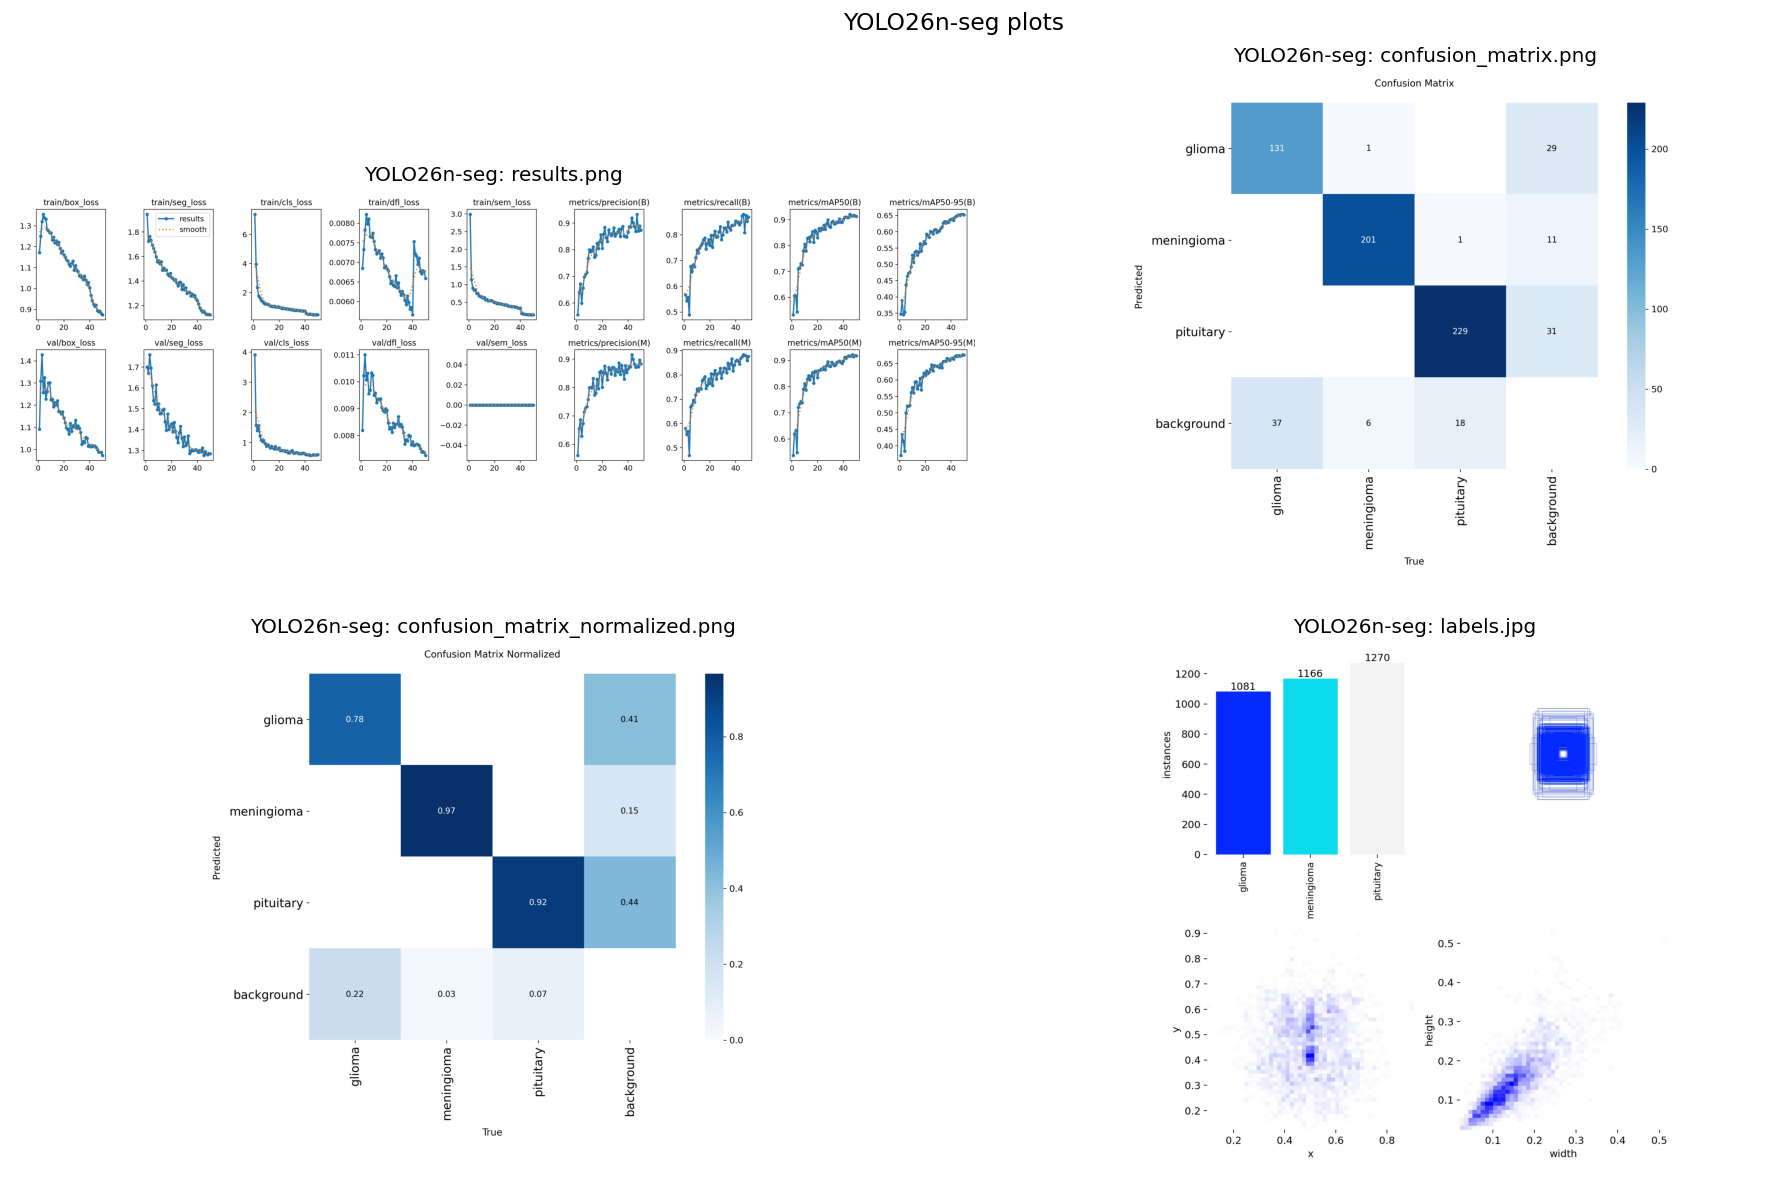

In [14]:
def show_plots(run_dir, model_name):
    plot_files = [
        "results.png", "confusion_matrix.png",
        "confusion_matrix_normalized.png", "PR_curve.png",
        "P_curve.png", "R_curve.png", "F1_curve.png",
        "labels.jpg", "labels_correlogram.jpg",
    ]

    found = [(p, run_dir / p) for p in plot_files if (run_dir / p).exists()]
    if not found:
        print(f"  No plots in {run_dir}")
        return

    cols = 2
    rows = (len(found) + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flatten()

    for i, (name, path) in enumerate(found):
        img = cv2.imread(str(path))
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"{model_name}: {name}")
        axes[i].axis("off")

    for i in range(len(found), len(axes)):
        axes[i].axis("off")

    plt.suptitle(f"{model_name} plots", fontsize=14)
    plt.tight_layout()
    plt.show()


v26_run = WORK_DIR / "runs" / "yolo26n_seg_brisc"

print("YOLO26n-seg plots:")
show_plots(v26_run, "YOLO26n-seg")

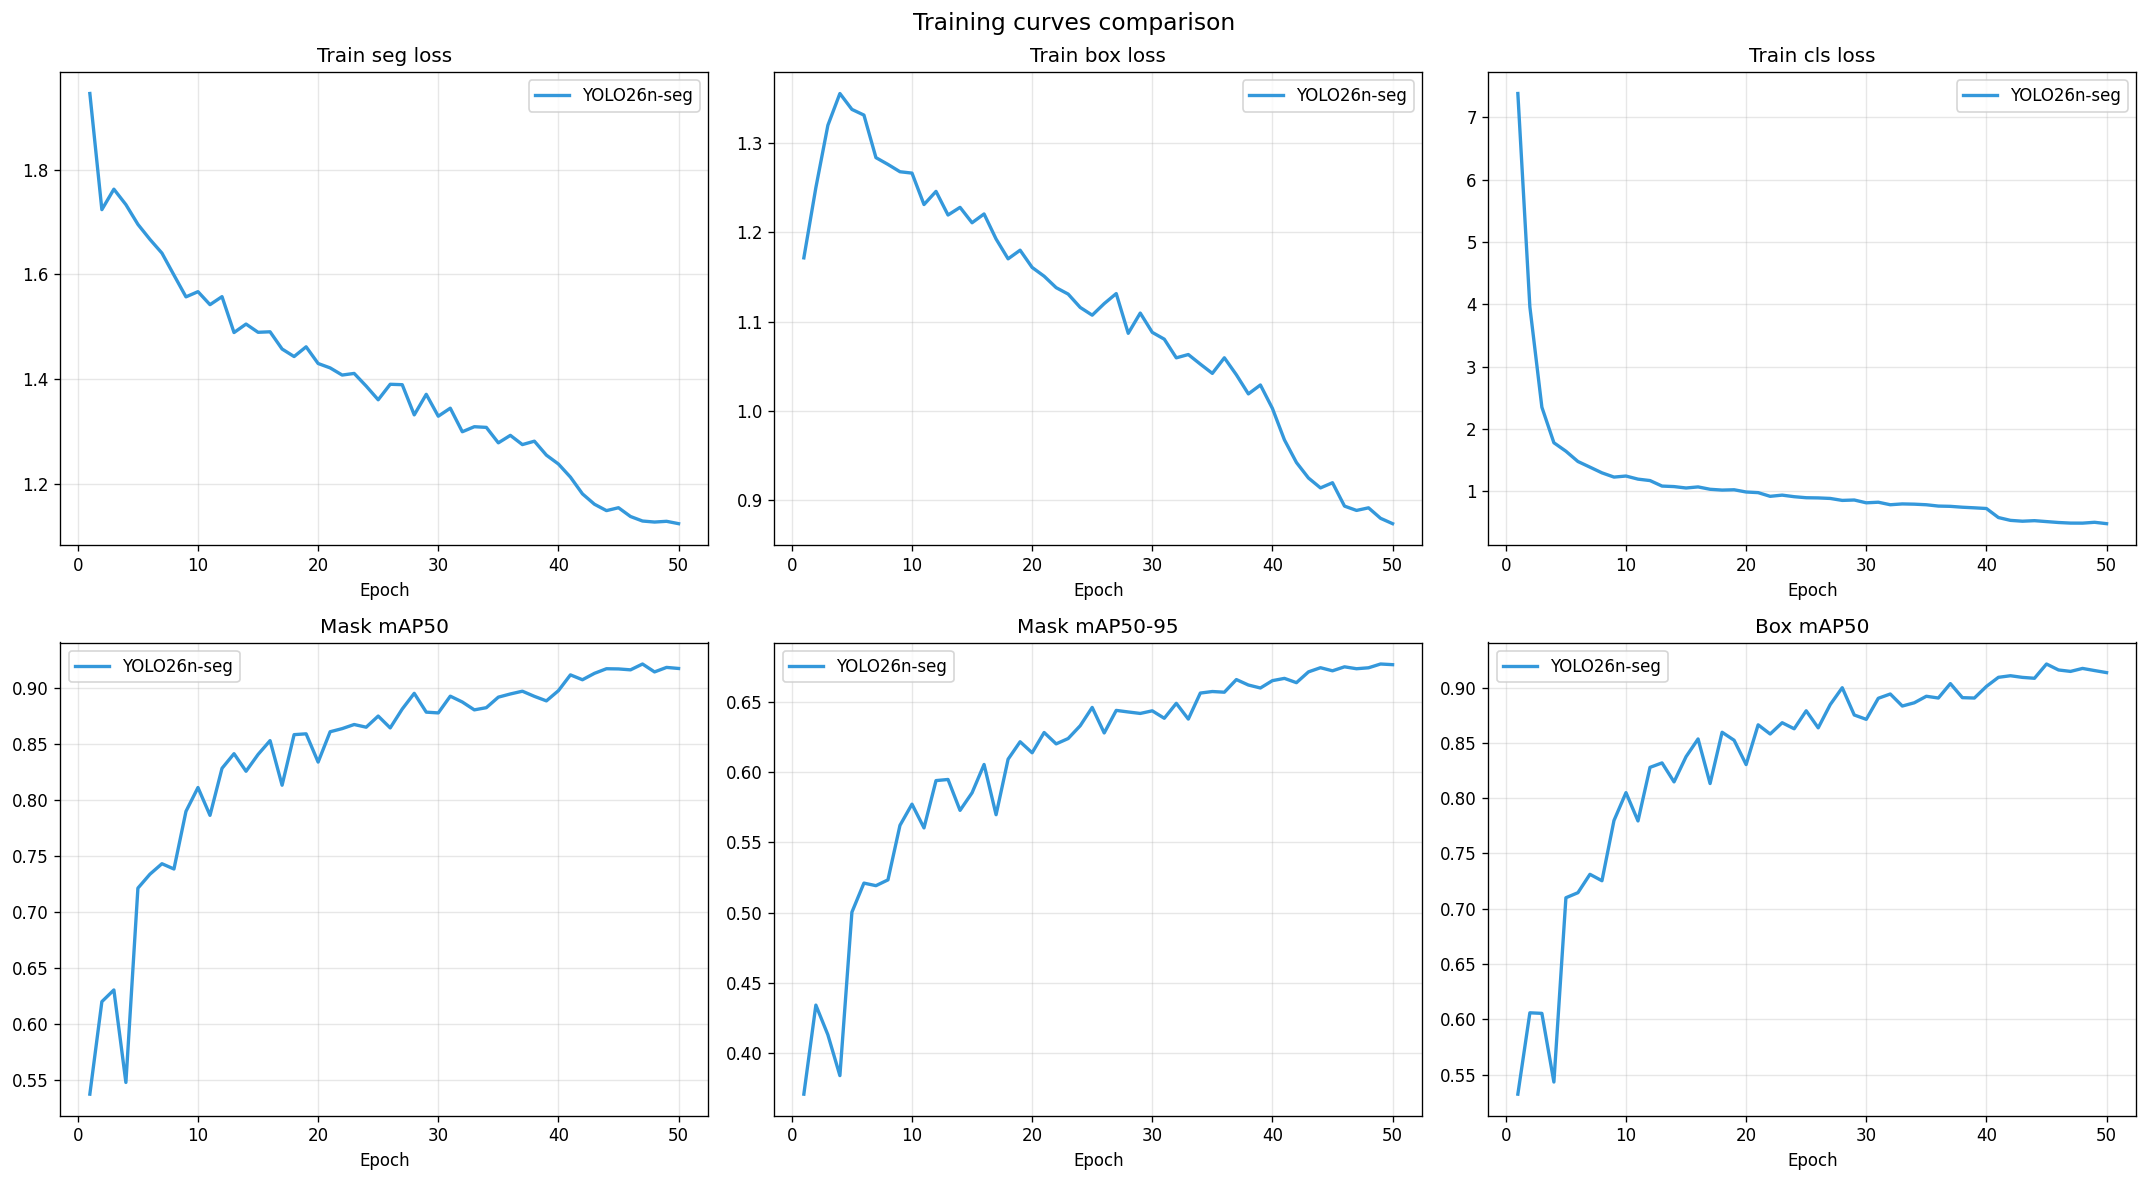

In [15]:
def load_results_csv(run_dir):
    csv_path = run_dir / "results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        return df
    return None

df_v26 = load_results_csv(v26_run)

if df_v26 is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # column names vary slightly between ultralytics versions
    # so we try a few patterns
    metric_cols = [
        ("train/seg_loss", "Train seg loss"),
        ("train/box_loss", "Train box loss"),
        ("train/cls_loss", "Train cls loss"),
        ("metrics/mAP50(M)", "Mask mAP50"),
        ("metrics/mAP50-95(M)", "Mask mAP50-95"),
        ("metrics/mAP50(B)", "Box mAP50"),
    ]

    for ax, (col, title) in zip(axes.flatten(), metric_cols):
        if col in df_v26.columns:
            ax.plot(df_v26["epoch"], df_v26[col], label="YOLO26n-seg", color="#3498db", linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle("Training curves", fontsize=14)
    plt.tight_layout()
    plt.savefig(WORK_DIR / "training_curves.png", dpi=150)
    plt.show()
else:
    print("Could not load training CSVs.")

## Test predictions

Prediction overlays show both models' segmentation masks on unseen test images.

YOLO26n-seg predictions:


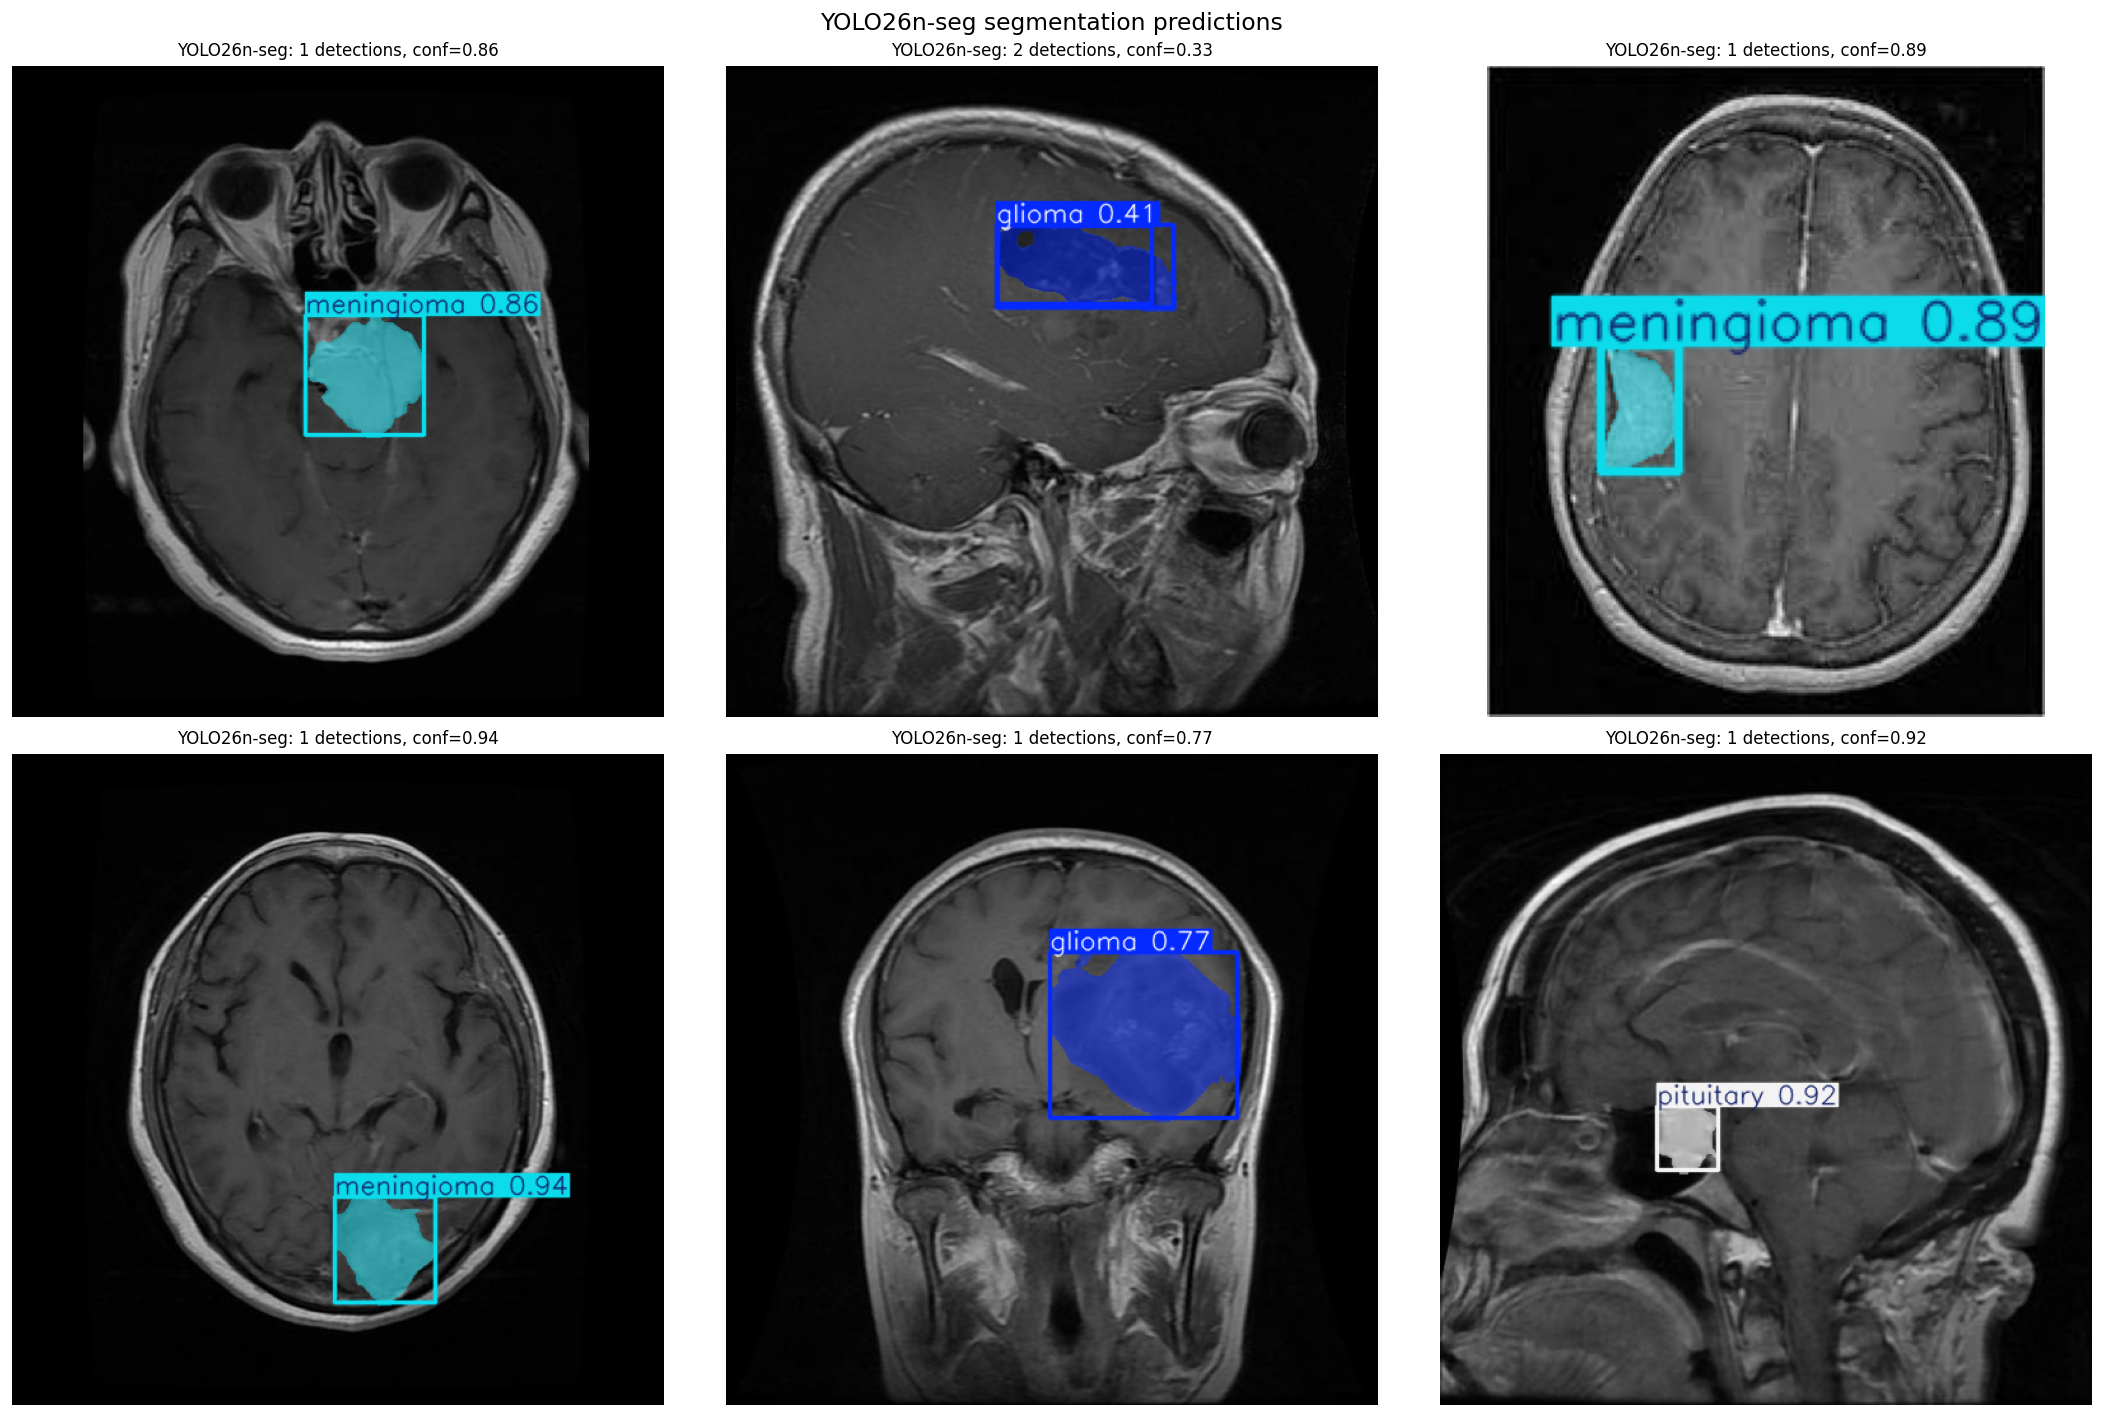

In [17]:
def predict_and_show(model_path, model_name, images, n=6):
    model = YOLO(model_path)
    results = model.predict(
        source=[str(img) for img in images[:n]],
        imgsz=640, conf=0.25, save=False, verbose=False,
    )

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, (r, img_path) in enumerate(zip(results, images[:n])):
        plotted = r.plot()
        plotted_rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        n_det = len(r.boxes) if r.boxes is not None else 0
        conf_str = ""
        if r.boxes is not None and len(r.boxes) > 0:
            confs = r.boxes.conf.cpu().numpy()
            conf_str = f", conf={confs.mean():.2f}"

        axes[i].imshow(plotted_rgb)
        axes[i].set_title(f"{model_name}: {n_det} detections{conf_str}", fontsize=10)
        axes[i].axis("off")

    plt.suptitle(f"{model_name} segmentation predictions", fontsize=14)
    plt.tight_layout()
    plt.savefig(WORK_DIR / f"{model_name.replace('-', '_').replace('.', '')}_predictions.png", dpi=150)
    plt.show()


test_images = sorted((YOLO_DATASET / "images" / "test").glob("*.jpg"))
if len(test_images) < 6:
    test_images += sorted((YOLO_DATASET / "images" / "val").glob("*.jpg"))
random.shuffle(test_images)

print("YOLO26n-seg predictions:")
predict_and_show(v26_best, "YOLO26n-seg", test_images)